<h5 style="color:#800020;">Hospital Dataset Preprocessing

This notebook performs preprocessing on the hospital dataset.

Steps:
- Merge datasets
- Analyze missing values
- Remove high-missing columns
- Restore important columns
- Fill missing values
- Remove duplicates
- Fix text issues
- Handle outliers
- Correct ages
- Save cleaned dataset</h5>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<h3 style="color:blue;">Read Files</h3>

In [30]:
triage_dataset = pd.read_csv("ED_triage.csv")
admission_dataset = pd.read_csv("ED_admission.csv")

In [31]:
print("Triage dataset :")
triage_dataset

Triage dataset :


,triage_code,gender,age,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,ChiefComplaint,...,BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation,AVPU,TriageGrade,operational_patient,ref_specialist
0,13960101008,Female,77,2017,3,21,2,2,5,Z03.89,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0,0
1,13960101009,Male,42,2017,3,21,2,2,6,T07,...,NaN,NaN,86.0,18.0,NaN,96.0,A,3,0,0
2,13960101010,Female,71,2017,3,21,2,2,6,R10.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
3,13960101011,Male,77,2017,3,21,2,2,6,R53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
4,13960101012,Male,39,2017,3,21,2,2,6,T79.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143577,14001229114,Female,55,2022,3,20,0,23,3,K92.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
143578,14001229115,Female,60,2022,3,20,0,23,6,T18.9,...,NaN,NaN,NaN,NaN,NaN,NaN,A,4,1,0
143579,14001229117,Female,70,2022,3,20,0,23,6,R55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
143580,14001229118,Male,67,2022,3,20,0,23,6,K92.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0


In [32]:
print("Admission dataset :")
admission_dataset

Admission dataset :


,triage_code,PatientCode,DischargeFromED,Foreigners,gender,age,marital_Status,ResidentDate_year,ResidentDate_month,ResidentDate_day,...,DischargeDate_hour,StatusOnDischarge,KindRef,IsGlobal,AccompainerRelation_id,ResidentDay,service_count_action,service_count_instrument,service_count_lab,service_count_graphy
0,13960101008,9600008,0,No,Female,75.0,2.0,2017,3,21,...,0,3,5,0.0,2.0,10.0,0,0,0,0
1,13960101009,9600009,0,No,Male,41.0,2.0,2017,3,21,...,0,2,6,0.0,3.0,2.0,0,0,0,0
2,13960101010,9600010,0,No,Female,71.0,2.0,2017,3,21,...,0,2,6,0.0,2.0,0.0,0,0,0,0
3,13960101011,9600011,0,No,Male,77.0,2.0,2017,3,21,...,0,3,6,0.0,2.0,9.0,0,0,0,0
4,13960101012,9600012,0,No,Male,38.0,2.0,2017,3,21,...,0,2,6,0.0,3.0,1.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143275,14001229114,140047327,1,No,Female,56.0,2.0,2022,3,20,...,0,2,3,0.0,3.0,4.0,0,0,0,0
143276,14001229115,140047328,1,No,Female,59.0,2.0,2022,3,20,...,0,2,4,0.0,2.0,1.0,0,0,0,0
143277,14001229117,140047329,1,No,Female,78.0,4.0,2022,3,20,...,0,3,4,0.0,3.0,17.0,0,0,0,0
143278,14001229118,140047330,1,No,Male,69.0,2.0,2022,3,20,...,0,2,4,0.0,2.0,4.0,0,0,0,0


<h3 style="color:blue;">Merge Files</h3>

In [33]:
hospital_dataset = pd.merge(triage_dataset , admission_dataset , on="triage_code" ,how="outer")

In [34]:
print("Files merged to create hospital dataset :")
hospital_dataset 

Files merged to create hospital dataset :


,triage_code,gender_x,age_x,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,ChiefComplaint,...,DischargeDate_hour,StatusOnDischarge,KindRef,IsGlobal,AccompainerRelation_id,ResidentDay,service_count_action,service_count_instrument,service_count_lab,service_count_graphy
0,13960101008,Female,77,2017,3,21,2,2,5,Z03.89,...,0.0,3.0,5.0,0.0,2.0,10.0,0.0,0.0,0.0,0.0
1,13960101009,Male,42,2017,3,21,2,2,6,T07,...,0.0,2.0,6.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0
2,13960101010,Female,71,2017,3,21,2,2,6,R10.84,...,0.0,2.0,6.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
3,13960101011,Male,77,2017,3,21,2,2,6,R53,...,0.0,3.0,6.0,0.0,2.0,9.0,0.0,0.0,0.0,0.0
4,13960101012,Male,39,2017,3,21,2,2,6,T79.9,...,0.0,2.0,6.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143633,14001229114,Female,55,2022,3,20,0,23,3,K92.2,...,0.0,2.0,3.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0
143634,14001229115,Female,60,2022,3,20,0,23,6,T18.9,...,0.0,2.0,4.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0
143635,14001229117,Female,70,2022,3,20,0,23,6,R55,...,0.0,3.0,4.0,0.0,3.0,17.0,0.0,0.0,0.0,0.0
143636,14001229118,Male,67,2022,3,20,0,23,6,K92.2,...,0.0,2.0,4.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0


<h3 style="color:blue;">Describe File</h3>

In [35]:
print("Hospital datase description :")
hospital_dataset.describe()

Hospital datase description :


,triage_code,age_x,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,explainer_id,NeedFastExecute,...,DischargeDate_hour,StatusOnDischarge,KindRef,IsGlobal,AccompainerRelation_id,ResidentDay,service_count_action,service_count_instrument,service_count_lab,service_count_graphy
count,1.436380e+05,143638.000000,143638.000000,143638.000000,143638.000000,143638.000000,143638.000000,143638.000000,34258.000000,143638.000000,...,143516.0,143516.000000,143516.000000,143515.000000,142726.000000,143515.000000,143516.0,143516.0,143516.0,143516.0
mean,1.397956e+10,47.628678,2019.094007,6.473823,15.753603,3.021157,13.452854,3.460185,2.820480,1.927269,...,0.0,2.135616,4.246223,0.007686,4.225208,4.210961,0.0,0.0,0.0,0.0
std,1.413002e+07,22.244400,1.473232,3.318751,8.805010,2.006101,6.858308,2.287221,0.676201,0.261459,...,0.0,0.653754,1.521139,0.087330,2.720345,9.086927,0.0,0.0,0.0,0.0
min,1.396010e+10,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.0
25%,1.397023e+10,30.000000,2018.000000,4.000000,8.000000,1.000000,9.000000,2.000000,2.000000,2.000000,...,0.0,2.000000,3.000000,0.000000,2.000000,0.000000,0.0,0.0,0.0,0.0
50%,1.398042e+10,47.000000,2019.000000,7.000000,16.000000,3.000000,14.000000,3.000000,3.000000,2.000000,...,0.0,2.000000,3.000000,0.000000,3.000000,1.000000,0.0,0.0,0.0,0.0
75%,1.399063e+10,65.000000,2020.000000,9.000000,23.000000,5.000000,19.000000,6.000000,3.000000,2.000000,...,0.0,2.000000,6.000000,0.000000,6.000000,5.000000,0.0,0.0,0.0,0.0
max,1.400123e+10,116.000000,2022.000000,12.000000,31.000000,6.000000,23.000000,6.000000,14.000000,2.000000,...,0.0,10.000000,7.000000,1.000000,10.000000,502.000000,0.0,0.0,0.0,0.0


In [36]:
print("Hospital dataset shape :" , hospital_dataset.shape)

Hospital dataset shape : (143638, 53)


<h4 style="color:green;">Number of missing values</h4>

In [59]:
print("Hospital dataset missing values each column :")
missing_values = hospital_dataset.isnull().sum()

Hospital dataset missing values each column :


<h4 style="color:green;">Missing Values Chart</h4>

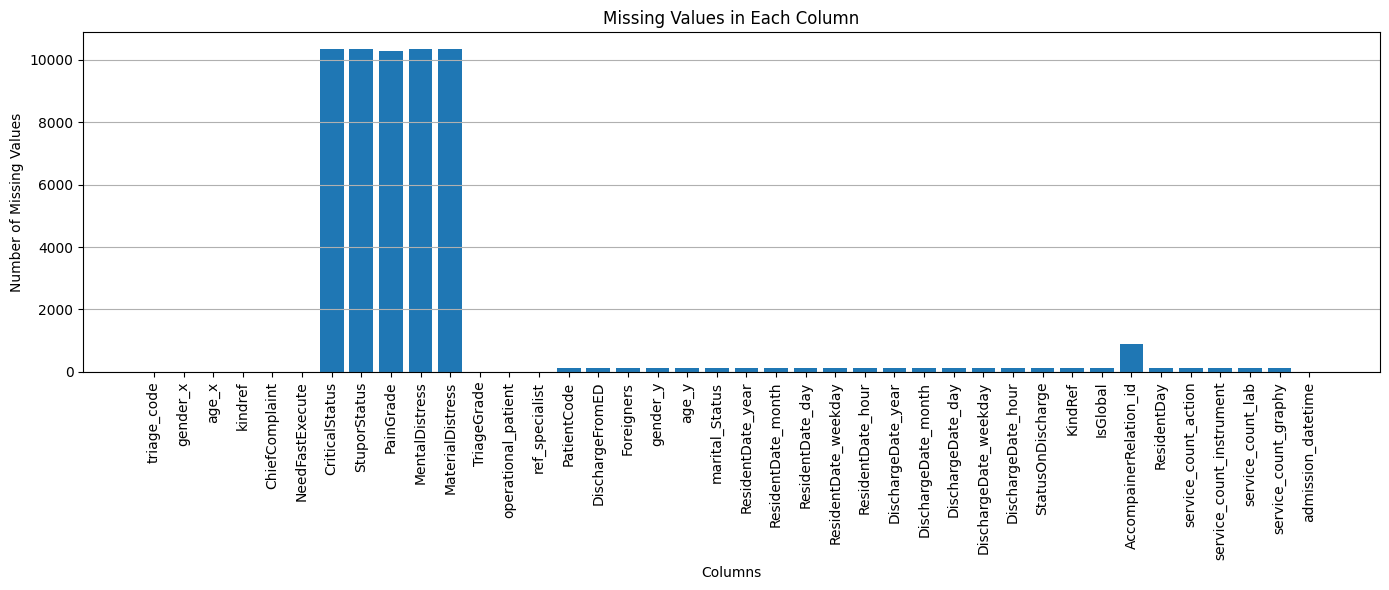

In [60]:
plt.figure(figsize=(14, 6))
plt.bar(missing_values.index, missing_values.values)
plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

<h3 style="color:blue;">Data Cleaning</h3>

<h4 style="color:green;">Removing columns with a high number of missing values</h4>

In [38]:
print("Dataset shape before removing missing value :",hospital_dataset.shape)

Dataset shape before removing missing value : (143638, 53)


In [40]:
while True:
    try:
        threshold = int(input("Enter threshold : "))
        break
    except ValueError:
        print("Please Enter a number.")
        continue
missing_percent = hospital_dataset.isnull().mean() * 100
cols_to_remove = missing_percent[missing_percent > threshold].index
high_missing_df = hospital_dataset[cols_to_remove].copy()
hospital_dataset = hospital_dataset.drop(columns=cols_to_remove)

Enter threshold :  


Please Enter a number.


Enter threshold :  20


In [41]:
print("Dataset shape after removed missing values :",hospital_dataset.shape)

Dataset shape after removed missing values : (143638, 44)


In [42]:
print(f"Missing values in {cols_to_remove} columns.")

Missing values in Index([], dtype='object') columns.


<h4 style="color:green;">If there are important columns, return them to the original DataFrame</h4>

In [43]:
important_list = []
while True:
    important_columns = input("Enter important columns : ")
    if important_columns == "end":
        break
    elif important_columns in high_missing_df.columns:
        important_list.append(important_columns)
        print("anything else ? ")
        continue
    else:
        print("Enter correct title.")
        continue
hospital_dataset[important_list] = high_missing_df[important_list]


Enter important columns :  end


<h4 style="color:green;">Fill missing values with mean or median</h4>

In [22]:
while True:
    column = input("Pleas enter a column for replacing missing values : ")
    if column == "end" :
        break
    if column in hospital_dataset.columns:
        question1 = input("Mean or median : ").lower()
        if question1 not in ["mean","median"] :
            print("Pleas enter mean or median.")
            continue
        if question1 == "mean" :
            hospital_dataset[column] = hospital_dataset[column].fillna(hospital_dataset[column].mean())
            print("Successfully replaced") 
        elif question1 == "median" :
            hospital_dataset[column] = hospital_dataset[column].fillna(hospital_dataset[column].median())
            print("Successfully replaced")
    else :
        print("Enter a valid column name.")

Pleas enter a column for replacing missing values :  ji


Enter a valid column name.


Pleas enter a column for replacing missing values :  KindRef
Mean or median :  mean


Successfully replaced


C:\Users\User\AppData\Local\Temp\ipykernel_18028\88048778.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hospital_dataset[column] = hospital_dataset[column].fillna(hospital_dataset[column].mean())


Pleas enter a column for replacing missing values :  end


<h4 style="color:green;">Remove Duplicates</h4>

In [44]:
hospital_dataset = hospital_dataset.drop_duplicates(subset=["triage_code"])
print("Duplicate values removed.")

Duplicate values removed.


<h4 style="color:green;">Fix textual issues</h4>


In [45]:
hospital_dataset["gender_x"] = hospital_dataset["gender_x"].str.strip().str.lower()
print("Text issues fixed.")

Text issues fixed.


<h4 style="color:green;">Fix times</h4>

In [46]:
hospital_dataset["admission_datetime"] = pd.to_datetime({
    "year": hospital_dataset["admission_year"],
    "month": hospital_dataset["admission_month"],
    "day": hospital_dataset["admission_day"],
    "hour": hospital_dataset["admission_hour"]
})
hospital_dataset.drop(
    columns=[
        "admission_year",
        "admission_month",
        "admission_day",
        "admission_weekday",
        "admission_hour"
    ],
    inplace=True
)
print("Time fixed.")

Time fixed.


<h4 style="color:green;">IQR</h4>

In [48]:
Q1 = hospital_dataset["ResidentDay"].quantile(0.25)
Q3 = hospital_dataset["ResidentDay"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = hospital_dataset[(hospital_dataset["ResidentDay"] < lower_bound) | (hospital_dataset["ResidentDay"] > upper_bound)]
print("IQR Outliers :")
outliers

IQR Outliers :


,triage_code,gender_x,age_x,kindref,ChiefComplaint,NeedFastExecute,CriticalStatus,StuporStatus,PainGrade,MentalDistress,...,StatusOnDischarge,KindRef,IsGlobal,AccompainerRelation_id,ResidentDay,service_count_action,service_count_instrument,service_count_lab,service_count_graphy,admission_datetime
11,13960101020,male,31,6,L03.90,2,2.0,2.0,3.0,2.0,...,2.0,6.0,0.0,6.0,15.0,0.0,0.0,0.0,0.0,2017-03-21 04:00:00
30,13960101039,female,73,3,R40.20,2,1.0,1.0,4.0,2.0,...,2.0,3.0,0.0,2.0,19.0,0.0,0.0,0.0,0.0,2017-03-21 11:00:00
58,13960101071,male,52,6,R06.00,2,1.0,2.0,4.0,2.0,...,2.0,6.0,0.0,3.0,17.0,0.0,0.0,0.0,0.0,2017-03-21 16:00:00
66,13960101079,female,94,5,R26,2,2.0,2.0,4.0,2.0,...,3.0,5.0,0.0,2.0,15.0,0.0,0.0,0.0,0.0,2017-03-21 17:00:00
80,13960101095,male,70,6,R06.00,2,0.0,0.0,0.0,2.0,...,2.0,6.0,0.0,2.0,22.0,0.0,0.0,0.0,0.0,2017-03-21 19:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143572,14001229018,female,75,3,W19,2,1.0,2.0,0.0,0.0,...,2.0,3.0,0.0,2.0,14.0,0.0,0.0,0.0,0.0,2022-03-20 06:00:00
143591,14001229057,female,58,6,R60.9,2,0.0,2.0,3.0,0.0,...,2.0,4.0,0.0,4.0,24.0,0.0,0.0,0.0,0.0,2022-03-20 13:00:00
143602,14001229073,male,80,6,R10.84,2,0.0,2.0,0.0,0.0,...,2.0,4.0,0.0,2.0,18.0,0.0,0.0,0.0,0.0,2022-03-20 15:00:00
143624,14001229099,male,46,6,R53,2,1.0,2.0,0.0,0.0,...,2.0,4.0,0.0,3.0,16.0,0.0,0.0,0.0,0.0,2022-03-20 21:00:00


<h4 style="color:green;">Checking IQR</h4>

In [49]:
outlier_percentage = (len(outliers) / len(hospital_dataset)) * 100
print(f"Outlier percentage : {outlier_percentage}")
print("Outliers description : ")
outliers["ResidentDay"].describe()

Outlier percentage : 7.658392979225091
Outliers description : 


count    10978.000000
mean        24.797413
std         22.465508
min         13.000000
25%         15.000000
50%         18.000000
75%         27.000000
max        502.000000
Name: ResidentDay, dtype: float64

In [51]:
while True:
    remove_outliers = input("Would you want to delete these outliers : ").lower()
    if remove_outliers == "yes":
        mix_dataset = hospital_dataset[(hospital_dataset["ResidentDay"] >= lower_bound) & (hospital_dataset["ResidentDay"] <= upper_bound)]
        print("Remove succesfully.")
        break
    elif remove_outliers == "no":
        print("Remove Canceled.")
        break
    else:
        print("Please enter Yes or No.")
        continue

Would you want to delete these outliers :  yes


Remove succesfully.


<h4 style="color:green;">Age correction</h4>

In [52]:
hospital_dataset = hospital_dataset[(hospital_dataset["age_x"] >= 0) & (hospital_dataset["age_x"] <= 120)]

<h4 style="color:green;">Save the final file</h4>

In [53]:
print("Final dataset :")
hospital_dataset

Final dataset :


,triage_code,gender_x,age_x,kindref,ChiefComplaint,NeedFastExecute,CriticalStatus,StuporStatus,PainGrade,MentalDistress,...,StatusOnDischarge,KindRef,IsGlobal,AccompainerRelation_id,ResidentDay,service_count_action,service_count_instrument,service_count_lab,service_count_graphy,admission_datetime
0,13960101008,female,77,5,Z03.89,2,0.0,0.0,0.0,0.0,...,3.0,5.0,0.0,2.0,10.0,0.0,0.0,0.0,0.0,2017-03-21 02:00:00
1,13960101009,male,42,6,T07,2,0.0,0.0,0.0,2.0,...,2.0,6.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,2017-03-21 02:00:00
2,13960101010,female,71,6,R10.84,2,1.0,2.0,0.0,2.0,...,2.0,6.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,2017-03-21 02:00:00
3,13960101011,male,77,6,R53,2,1.0,0.0,0.0,2.0,...,3.0,6.0,0.0,2.0,9.0,0.0,0.0,0.0,0.0,2017-03-21 02:00:00
4,13960101012,male,39,6,T79.9,2,0.0,0.0,0.0,2.0,...,2.0,6.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,2017-03-21 02:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143633,14001229114,female,55,3,K92.2,2,1.0,2.0,0.0,0.0,...,2.0,3.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0,2022-03-20 23:00:00
143634,14001229115,female,60,6,T18.9,2,0.0,2.0,3.0,0.0,...,2.0,4.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,2022-03-20 23:00:00
143635,14001229117,female,70,6,R55,1,NaN,NaN,NaN,NaN,...,3.0,4.0,0.0,3.0,17.0,0.0,0.0,0.0,0.0,2022-03-20 23:00:00
143636,14001229118,male,67,6,K92.2,2,1.0,2.0,0.0,0.0,...,2.0,4.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,2022-03-20 23:00:00


In [54]:
hospital_dataset.to_csv("hospital_dataset_final.csv", index=False)
print("File seved")

File seved
